# Figure Paper


In [ ]:
savepath = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"

## Network structure - (from drawio site) 

In [3]:
import keras
from keras import layers
import numpy as np
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import pandas as pd 
from _GAN_utils import SelfAttention3D, load_data

latent_dim=64
height = 16; width = 16; depth = 16; channels = 8
gen_input_latent = keras.Input(shape=(latent_dim,))
x = layers.Dense(4 * 4 * 4,activation="relu")(gen_input_latent)
x = layers.Reshape((4, 4, 4, 1))(x)
x = layers.Conv3D(16, 4, activation="relu", padding="same")(x)
x = layers.Conv3DTranspose(32, 6, strides=2,activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv3D(32, 6, activation="relu", padding="same")(x)
x = SelfAttention3D(32)(x)           
x = layers.Conv3DTranspose(32, 8, 2,activation="relu", padding="same")(x)
x = layers.Conv3D(32, 3,activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Conv3D(8, 3,activation="relu", padding="same")(x)
x = layers.Conv3D(channels, 3, activation='sigmoid', padding="same")(x);  

generator_WGAN_AC = keras.models.Model(gen_input_latent, x,name="generator")


crit_input_img = layers.Input(shape=(height, width, depth, channels))
y = layers.Conv3D(32, 4, strides=2, activation="leaky_relu", padding="same")(crit_input_img)
y = layers.Conv3D(64, 3, activation="leaky_relu", padding="same")(y)
y = SelfAttention3D(64)(y)
y = layers.Conv3D(64, 3, activation="leaky_relu", padding="same")(y)
y = layers.Dropout(0.25)(y)
y = layers.Conv3D(32, 3, activation="leaky_relu", padding="same")(y)
y = layers.LayerNormalization(axis=[1,2])(y)
y = layers.Dropout(0.25)(y)
y = layers.Conv3D(8, 3, activation="leaky_relu", padding="same")(y)
y = layers.Flatten()(y)
wass_out = layers.Dense(64,activation="leaky_relu")(y)
wass_out = layers.Dense(1)(wass_out)
critic_WGAN_AC = keras.models.Model(crit_input_img, wass_out, name="critic")

## MC simulate data - binned

In [ ]:
#del plot_img
def plot_img(u, indice, cmap="viridis", log=True, pathsave=None, th_npart=0):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.tight_layout(pad=4.0)
    fontsize = 16
    # Panel 1: py vs px
    quali1 = u[indice].sum(axis=(-1,-2))
    quali1 = np.where(quali1<th_npart, 0, quali1)
    if log:
        im1 = axes[0, 0].imshow(np.log10(quali1), cmap=cmap)
    else: 
        im1 = axes[0, 0].imshow(quali1, cmap=cmap)
    axes[0, 0].set_xlabel("py",fontsize=fontsize); axes[0, 0].set_ylabel("px",fontsize=fontsize)
    fig.colorbar(im1, ax=axes[0, 0])
    # axes[0, 0].set_title("px vs py")

    # Panel 3: pz vs px
    quali3 = u[indice].sum(axis=(0,-1))
    quali3 = np.where(quali3<th_npart, 0, quali3)
    if log:
        im3 = axes[1, 0].imshow(np.log10(quali3), cmap=cmap)   
    else: 
        im3 = axes[1, 0].imshow(quali3, cmap=cmap)  
    axes[1, 0].set_xlabel("pz",fontsize=fontsize); axes[1, 0].set_ylabel("px",fontsize=fontsize)
    fig.colorbar(im3, ax=axes[1, 0])
    # axes[1, 0].set_title("px vs pz")

    # Panel 2: r vs px
    quali2 = u[indice].sum(axis=(0,2))
    quali2 = np.where(quali2<th_npart, 0, quali2)
    if log:
        im2 = axes[0, 1].imshow(np.log10(quali2), cmap=cmap)
    else: 
        im2 = axes[0, 1].imshow(quali2, cmap=cmap)
    
    axes[0, 1].set_xlabel("r",fontsize=fontsize); axes[0, 1].set_ylabel("px",fontsize=fontsize)
    fig.colorbar(im2, ax=axes[0, 1])
    # axes[0, 1].set_title("px vs Log10_r")

    # Panel 4: Log10_r vs Log10_pz
    quali4 = u[indice].sum(axis=(0,1))
    quali4 = np.where(quali4<th_npart, 0, quali4)
    if log:
        im4 = axes[1, 1].imshow(np.log10(quali4), cmap=cmap)
    else: 
        im4 = axes[1, 1].imshow(quali4, cmap=cmap)
    axes[1, 1].set_xlabel("r",fontsize=fontsize); axes[1, 1].set_ylabel("pz",fontsize=fontsize)
    fig.colorbar(im4, ax=axes[1, 1])
    
    # axes[1, 1].set_title("Log10_pz vs Log10_r")
    if pathsave:
        plt.savefig(f"{pathsave}.png", bbox_inches='tight', dpi=300)  # high-res output
    plt.suptitle(f"{indice}")
    
    plt.show()
    plt.clf()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

try: 
    del plot_tante_img
except:
    pass

def plot_tante_img(immagini, indici, cmap="viridis", log=True, pathsave=None):
    """
    Crete plot 4x4:
    """
    fig = plt.figure(figsize=(20, 20))
    gs = GridSpec(4, 5, figure=fig, width_ratios=[1, 1, 1, 1, 0.05], height_ratios=[1, 1, 0.75,0.75], hspace=-0.43, wspace=0.15 )
    axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(4)] for i in range(4)])
    cbar_axes = [fig.add_subplot(gs[i, 4]) for i in range(4)]

    fontsize = 18
    gpxpy = []
    gpzpx = []
    grpx = []
    grpz = []

    for i,indice in enumerate(indici[0:4]):
        # --- 1. px vs py ---
        gpxpy.append(immagini[indice].sum(axis=(-1, -2)))
        # --- 2. pz vs px ---
        gpzpx.append(immagini[indice].sum(axis=(1, -1)).T)
        # --- 3. r vs px ---
        grpx.append(immagini[indice].sum(axis=(1, 2)).T)
        # --- 4. r vs pz ---
        grpz.append(immagini[indice].sum(axis=(1, 0)).T)

    vmax1 = max([np.max(gpxpy[i]) for i in range(len(gpxpy))])
    vmax2 = max([np.max(gpzpx[i]) for i in range(len(gpxpy))])
    vmax3 = max([np.max(grpx[i]) for i in range(len(gpxpy))])
    vmax4 = max([np.max(grpz[i]) for i in range(len(gpxpy))])


    panels = [
            (gpxpy, "py", "px", vmax1),
            (gpzpx, "px", "pz", vmax2),
            (grpx, "px", "r", vmax3),
            (grpz, "pz", "r", vmax4),
            ]


        # --- Ciclo su ciascun tipo di proiezione ---
    for i, (bidimprojection, xlabel, ylabel, vmax) in enumerate(panels):
        for j in range(len(gpxpy)):

            vmin = 0

            if log:
                vmax_cbar = np.log10(vmax)
                data = np.log10(bidimprojection[j])

            else:
                data = bidimprojection[j]
                vmax_cbar = vmax



            print (vmin ,vmax_cbar)

            # Riga 1: vere
            im = axes[i, j].imshow(data, cmap=cmap, vmin=vmin, vmax=vmax_cbar)#, aspect='auto')
            
            axes[i, j].invert_yaxis()
            #axes[0, i].set_title(f"Vere ({ylabel}-{xlabel})", fontsize=fontsize)
            #axes[0, i].set_xlabel(xlabel, fontsize=fontsize)
            if j == 0:
                axes[i, j].set_ylabel(ylabel, fontsize=fontsize)
            
            if i != 3:
                axes[i, j].set_xticks([])

            if j != 0:
                axes[i, j].set_yticks([])
                

            
            axes[i, j].set_xlabel(xlabel, fontsize=fontsize)
        pos = axes[i, -1].get_position()  # position of last subplot in row
        cbpos = cbar_axes[i].get_position()

        # center the colorbar vertically
        cbar_axes[i].set_position([
            cbpos.x0, 
            pos.y0,  # adjust offset
            cbpos.width, 
            pos.height            # shrink height a bit
        ])
        cbar = fig.colorbar(im, cax=cbar_axes[i])
        cbar.set_label("N particles (log scale)", fontsize=fontsize-4)



    if pathsave:
        plt.savefig(f"{pathsave}.png", bbox_inches='tight', dpi=300)
    plt.show()
    plt.clf()

/tmp/ipykernel_2467252/171401620.py:58: RuntimeWarning: divide by zero encountered in log10
  data = np.log10(bidimprojection[j])


0 3.281260687055013
0 3.281260687055013
0 3.281260687055013
0 3.281260687055013
0 3.056142262059052
0 3.056142262059052
0 3.056142262059052
0 3.056142262059052
0 3.4497868469857735
0 3.4497868469857735
0 3.4497868469857735
0 3.4497868469857735
0 3.3027637084729817
0 3.3027637084729817
0 3.3027637084729817
0 3.3027637084729817


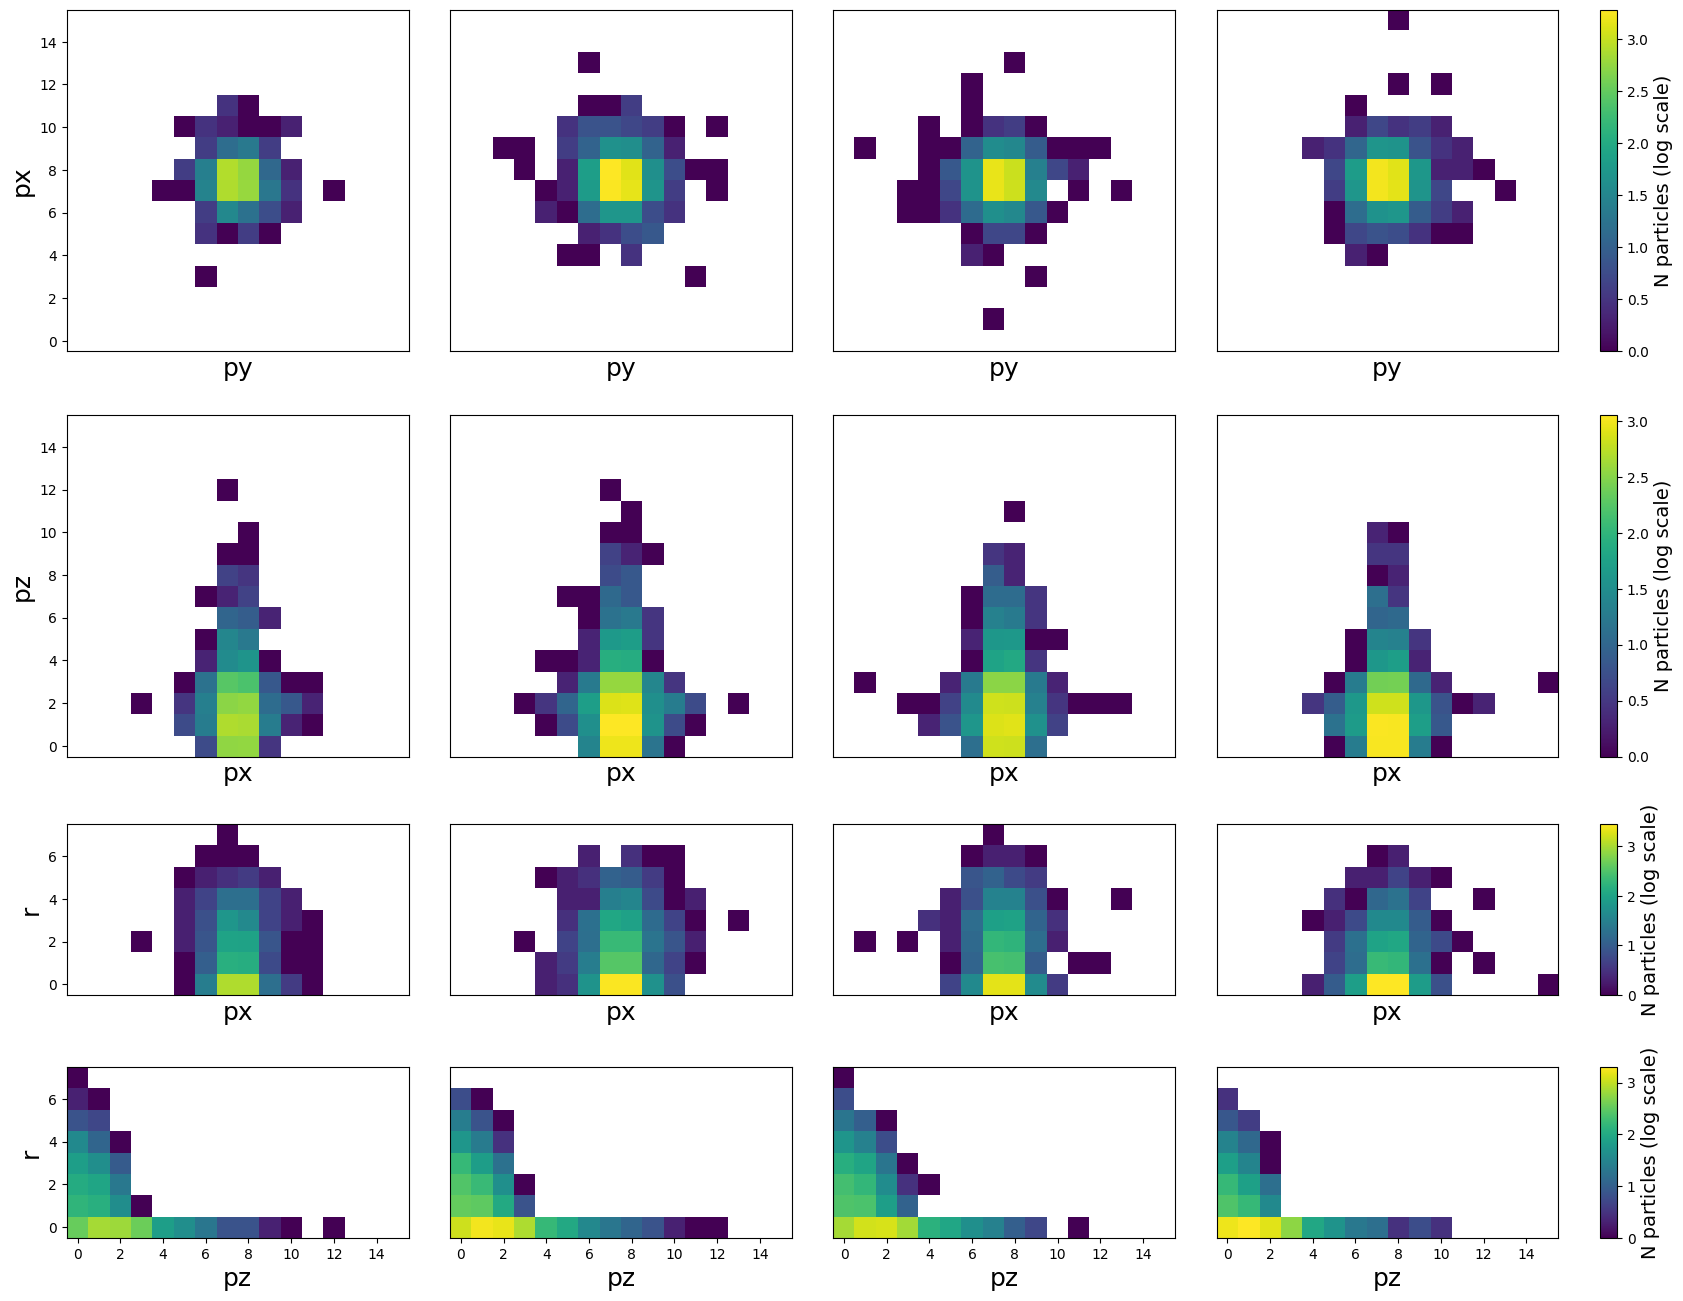

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
from skimage.measure import block_reduce
import matplotlib.pyplot as plt

z = 13; y = 34-2*z; x = z-2
dat_tot = np.load(f"../DataCorsika7/img_data/path_zexm/mu_p_data_path_zexm.npy")

merged = block_reduce(dat_tot,
                      block_size=(1, 2, 2, 1, 2),
                      func=np.sum)
un = block_reduce(merged[:,:,:,:y,:],
                      block_size=(1, 1, 1, 2, 1),
                      func=np.sum)
du = merged[:,:,:,y:32-z,:]
tre = merged[:,:,:,32-z:,:].sum(axis=3,keepdims=True)
data_under_resol = np.concatenate((un,du,tre),axis=3)

path = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"
ok_Mc = [14,5,13,17]
#for i in [14,5,13,17]:
    #plot_img(data_under_resol,i,pathsave=f"{path}Img_reali_{i}")

plot_tante_img(data_under_resol,ok_Mc,pathsave=f"{path}Img_MC")

## Some generated IMG

In [ ]:
import keras
from keras import layers
import numpy as np
import tensorflow as tf
import subprocess
import matplotlib.pyplot as plt
import subprocess
import pandas as pd 
from _GAN_utils import SelfAttention3D

def build_generator():
    try:
        def get_gpu_memory_usage():
            command = "nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits"
            memory_usage = subprocess.check_output(command, shell=True).decode("utf-8").strip().split("\n")
            memory_usage = [int(memory) for memory in memory_usage]
            return memory_usage
        mem_usage = get_gpu_memory_usage()
        # Allow memory growth to prevent TensorFlow from allocating all GPU memory at once
        gpus = tf.config.experimental.list_physical_devices('GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        # Specify which GPU to use for this script
        # For example, to use GPU 1: tf.config.experimental.set_visible_devices(gpus[1], 'GPU')
        tf.config.experimental.set_visible_devices(gpus[np.argmin(mem_usage)], 'GPU')
    except Exception as e:
        print(f"VADO AVANTI, non scelgo device tf: {e} \n")

    latent_dim = 64; channels=8
    gen_input_latent = keras.Input(shape=(latent_dim,))
    x = layers.Dense(4 * 4 * 4,activation="relu")(gen_input_latent)
    x = layers.Reshape((4, 4, 4, 1))(x)
    x = layers.Conv3D(16, 4, activation="relu", padding="same")(x)
    x = layers.Conv3DTranspose(32, 6, strides=2,activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(32, 6, activation="relu", padding="same")(x)
    x = SelfAttention3D(32)(x)           
    x = layers.Conv3DTranspose(32, 8, 2,activation="relu", padding="same")(x)
    x = layers.Conv3D(32, 3,activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(8, 3,activation="relu", padding="same")(x)
    x = layers.Conv3D(channels, 3, activation='sigmoid', padding="same")(x)
    return keras.models.Model(gen_input_latent, x,name="generator")

n_generated = 50
th = 0.22
seed = 5728

path = "../GitHubFolders/GAN_GAIAS2/GAN/WGAN/"
savepath = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"

tag = "2025-09-14_10_05_29_WGAN_GP_corsika_NotConditioned_exceptfirst4_weigdecay_bigkernel"
orario = "2025-09-14_10_05_29"
epoca = 2250
 
generator_WGAN_AC = build_generator()
ok = [10,4,2,0] # gli originari, per epoca 3870

npart_ok = []

oks=[[10,4,2],[45]]
epoches = [3870,2250]
for ok, epoca in zip(oks, epoches):
    generator_WGAN_AC.load_weights(f"{path}{tag}/generator_{tag}_{epoca}.keras")


    tf.random.set_seed(seed)

    random_latent_vectors = tf.random.normal(shape=(n_generated, 64))
    generated_images = generator_WGAN_AC(random_latent_vectors)

    npart = 10**(generated_images*3.9) - 1
    npnpart = np.array(npart)
    npnpart_clip = np.where( npnpart <th , 0, npnpart)
    npnpart_clip = np.where( (npnpart_clip >=th) & (npnpart_clip <1) , 1, npnpart_clip)
    for i in ok:
        npart_ok.append(npnpart_clip[i])

npart_ok = np.array(npart_ok)
# for i in range(11):
#     plot_img(npnpart_clip,i)#,pathsave=f"{savepath}Img_generate_{i}_epoca_{epoca}_seed_{seed}")

2025-10-25 17:13:12.945844: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43681 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6
2025-10-25 17:13:14.175796: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1761408794.252158 2467252 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761408794.284609 2467252 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761408794.286322 2467252 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761408794.288387 2467252 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761408794.300039 2467252 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761408794.301679 246

/tmp/ipykernel_2467252/171401620.py:58: RuntimeWarning: divide by zero encountered in log10
  data = np.log10(bidimprojection[j])


0 3.5489194
0 3.5489194
0 3.5489194
0 3.5489194
0 3.4499083
0 3.4499083
0 3.4499083
0 3.4499083
0 3.789076
0 3.789076
0 3.789076
0 3.789076
0 3.4536533
0 3.4536533
0 3.4536533
0 3.4536533


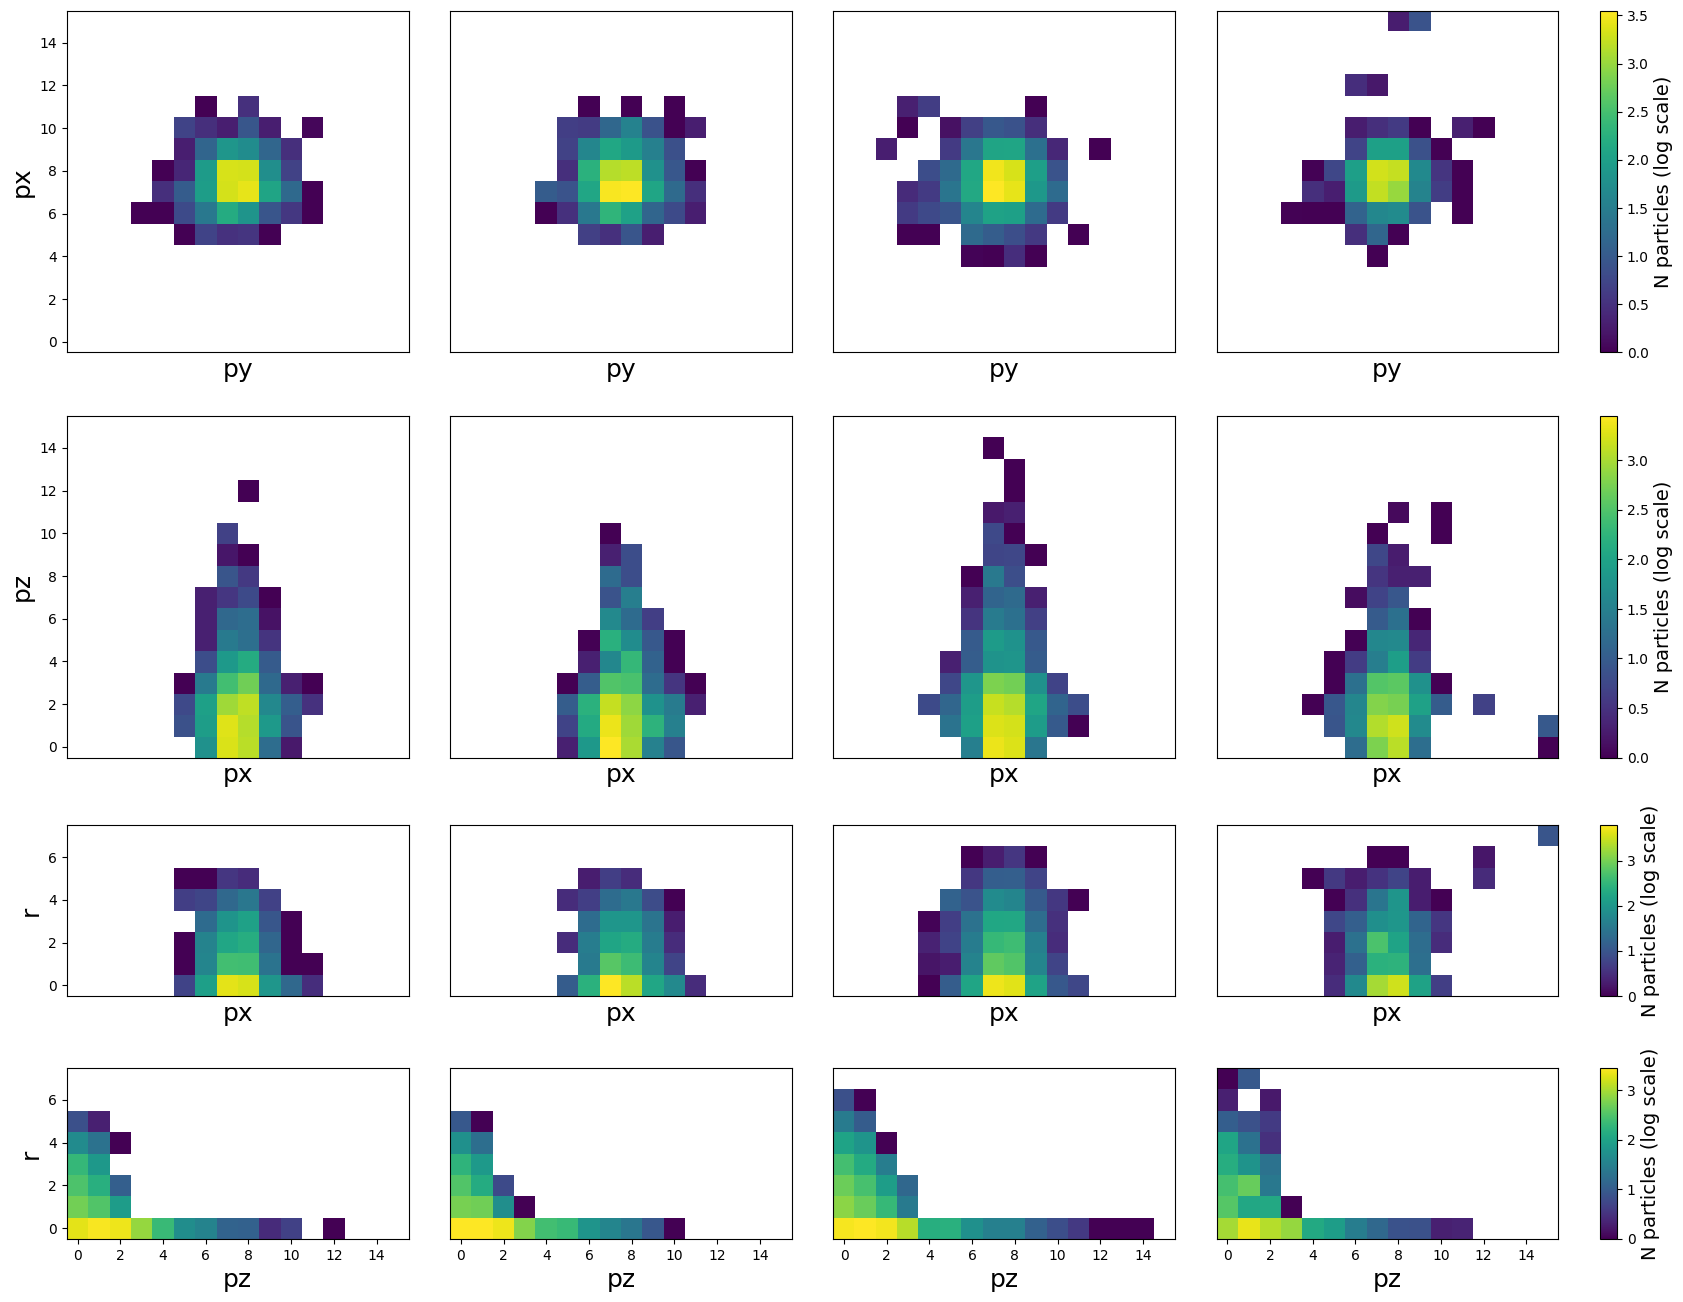

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_tante_img(npart_ok,[0,1,2,3], pathsave=f"{savepath}Img_generate")

## Final satistics for bins

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from _GAN_utils import load_data

x_train, labels, network_details_stringa = load_data("../DataCorsika7/img_data/76310_1e6_2e7/", "1e6-2e7", "76310")
x_train2 = 10**(x_train*3.9) -1

pat = "2025-09-14_10_05_29_WGAN_GP_corsika_NotConditioned_exceptfirst4_weigdecay_bigkernel/"

statistics = pd.read_csv("Statistiche_distr_num_part.csv")
epoche = statistics["epoch"].values
epoche[0] = 0


good_epochs = list(statistics[(statistics["Wasserstein_distance_from_real"]<0.1) * (statistics["epoch"].astype(int)>500)]["epoch"])
tuttigen = []
for epoca in good_epochs:
    tuttigen.append(np.load(pat+"epoca_"+epoca+"/gen_data.npy"))
tuttigen2 = np.concatenate(tuttigen, axis=0)


2025-10-24 15:45:45.796806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-24 15:45:45.823283: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-24 15:45:45.831367: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-24 15:45:45.853672: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-24 15:45:47.772381: W tensorflow/compiler/tf2

loaded [21.26 s]
concatenated data [162.36 s]
block reduced data - 1 [298.42 s]
block reduced data - 2 [303.81 s]
concatenated un, du, tre [310.21 s]
Scaled data [318.67 s]


In [2]:
px_mean_gen = tuttigen2.sum(axis=(-1,-2,-3))
px_std_gen = px_mean_gen.std(axis=0)
px_mean_gen = px_mean_gen.mean(axis=0)

py_mean_gen = tuttigen2.sum(axis=(-1,-2,1))
py_std_gen = py_mean_gen.std(axis=0)
py_mean_gen = py_mean_gen.mean(axis=0)

pz_mean_gen = tuttigen2.sum(axis=(1,2,4))
pz_std_gen = pz_mean_gen.std(axis=0)
pz_mean_gen = pz_mean_gen.mean(axis=0)


r_mean_gen = tuttigen2.sum(axis=(1,2,3))
r_std_gen = r_mean_gen.std(axis=0)
r_mean_gen = r_mean_gen.mean(axis=0)

In [3]:
px_mean_real = x_train2.sum(axis=(-1,-2,-3))
px_std_real = px_mean_real.std(axis=0)
px_mean_real = px_mean_real.mean(axis=0)

py_mean_real = x_train2.sum(axis=(-1,-2,1))
py_std_real = py_mean_real.std(axis=0)
py_mean_real = py_mean_real.mean(axis=0)


pz_mean_real = x_train2.sum(axis=(1,2,4))
pz_std_real = pz_mean_real.std(axis=0)
pz_mean_real = pz_mean_real.mean(axis=0)


r_mean_real = x_train2.sum(axis=(1,2,3))
r_std_real = r_mean_real.std(axis=0)
r_mean_real = r_mean_real.mean(axis=0)

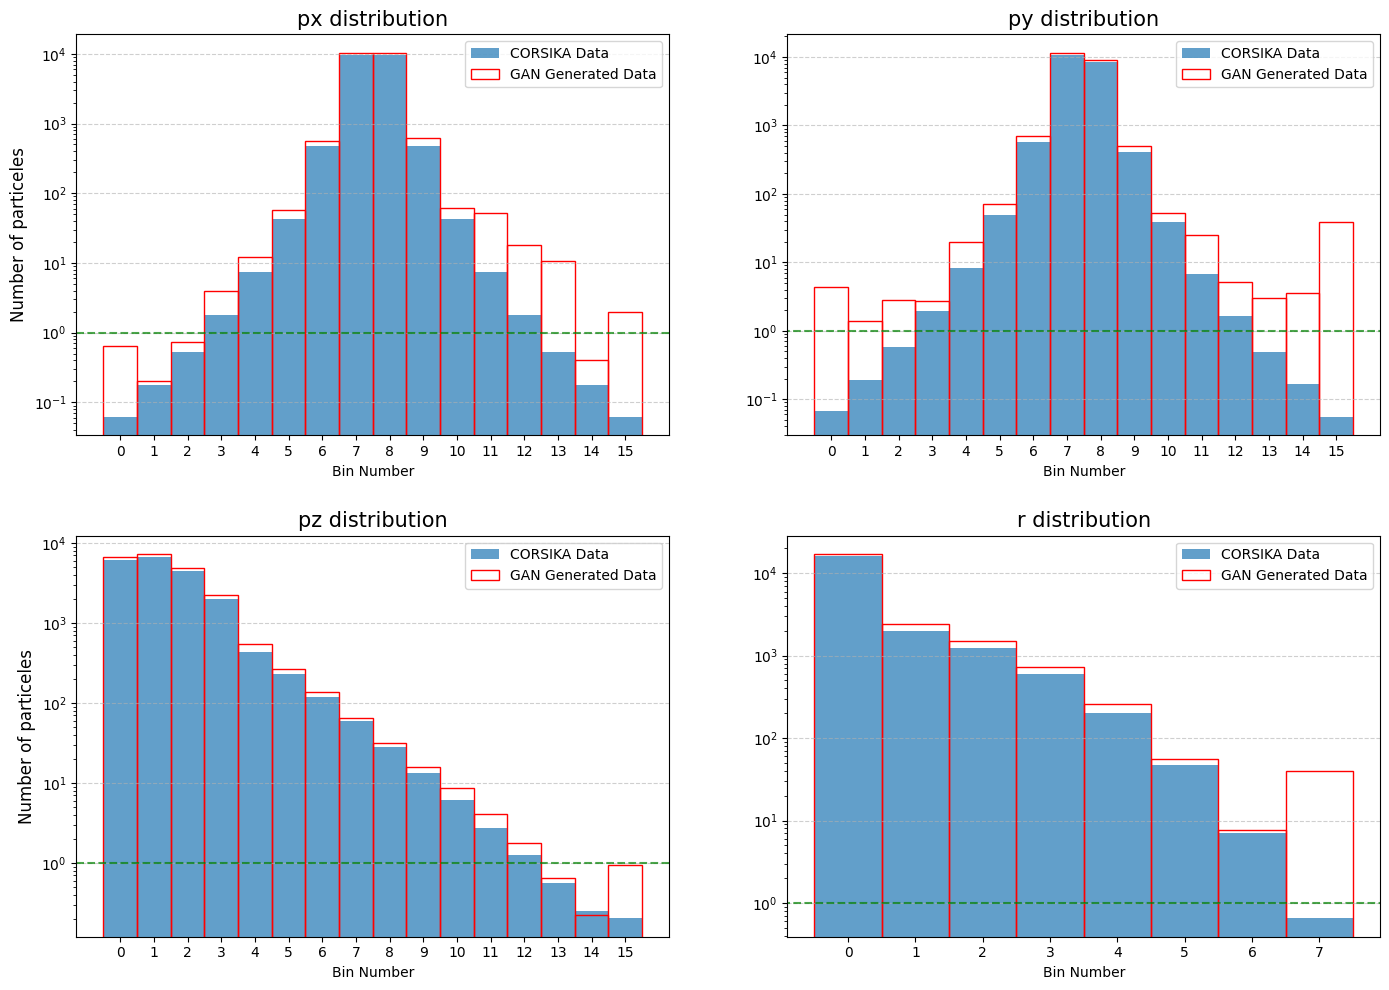

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

savepath = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"
density = False
shift = 0
width = 1
#shift = 0.3
#width = 0.3

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()  # così possiamo iterare facilmente

data = [
    ("px", px_mean_real, px_std_real, px_mean_gen, px_std_gen),
    ("py", py_mean_real, py_std_real, py_mean_gen, py_std_gen),
    ("pz", pz_mean_real, pz_std_real, pz_mean_gen, pz_std_gen),
    ("r",  r_mean_real,  r_std_real,  r_mean_gen,  r_std_gen),
]

for i, (label, mean_real, std_real, mean_gen, std_gen) in enumerate(data):
    bins = np.arange(len(mean_real))
    ax = axs[i]
    uno = 1
    cento = 100
    
    if density:
        uno = 1 / np.sum(mean_real)
        cento = 100 / np.sum(mean_real)
        mean_real = mean_real / np.sum(mean_real)
        mean_gen = mean_gen / np.sum(mean_gen)
    # Plot delle barre (trasparenza per migliorare visibilità)
    ax.bar(
        bins-shift , mean_real, width=width,
        #facecolor="blue", #edgecolor="blue", linewidth=1.8,
        #yerr=std_real,
        #error_kw=dict(ecolor="blue", lw=1, capsize=4),
        alpha=0.7,
        label="CORSIKA Data"
    )
    ax.bar(
        bins+shift , mean_gen, width=width,
        facecolor="None", edgecolor="red", linewidth=1,
        #yerr=std_gen,
        #error_kw=dict(ecolor="red", lw=1, capsize=4),
        label="GAN Generated Data"
    )

    ax.set_title(f"{label} distribution", fontsize=15, )
    ax.set_xlabel("Bin Number")
    if i % 2 == 0:
        ax.set_ylabel("Number of particeles", fontsize=12)
    ax.set_xticks(bins)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_yscale("log")
    ax.legend()
    xlim = ax.set_xlim()
    ax.hlines(uno, bins[0]-10, bins[-1]+10, colors='green', linestyles='dashed', alpha=0.7)
    ax.set_xlim(xlim)
# Spaziatura e layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.2)

#plt.savefig(f"{savepath}Final_distributions_comparison.png", bbox_inches='tight', dpi=300)
plt.show()


### Tutte separate

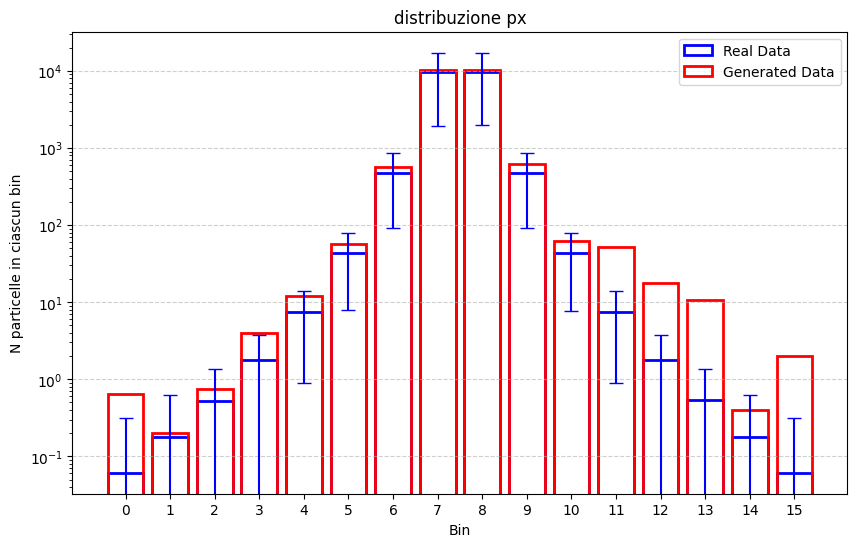

In [ ]:
bins = np.arange(len(px_mean_real))

plt.figure(figsize=(10,6))
# plt.bar(bins, px_mean_real, yerr=px_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5))
# plt.bar(bins, px_mean_gen, yerr=px_std_gen, capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5) )
plt.bar(bins, px_mean_real, yerr=px_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5), label ="Real Data")
plt.bar(bins, px_mean_gen,  capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5), label ="Generated Data")

plt.xlabel("Bin")
plt.ylabel("N particelle in ciascun bin")
plt.title("distribuzione px")
plt.xticks(bins)  # mostra i numeri dei bin sull'asse x
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.legend()

plt.show()


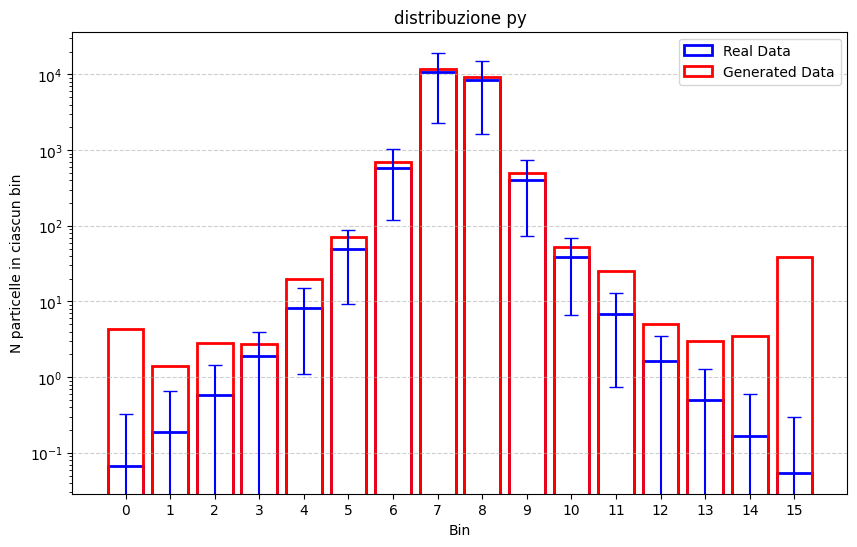

In [ ]:
bins = np.arange(len(py_mean_real))

plt.figure(figsize=(10,6))
# plt.bar(bins, px_mean_real, yerr=px_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5))
# plt.bar(bins, px_mean_gen, yerr=px_std_gen, capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5) )
plt.bar(bins, py_mean_real, yerr=py_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5), label ="Real Data")
plt.bar(bins, py_mean_gen,  capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5) , label ="Generated Data")

plt.xlabel("Bin")
plt.ylabel("N particelle in ciascun bin")
plt.title("distribuzione py")
plt.xticks(bins)  # mostra i numeri dei bin sull'asse x
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.legend()

plt.show()

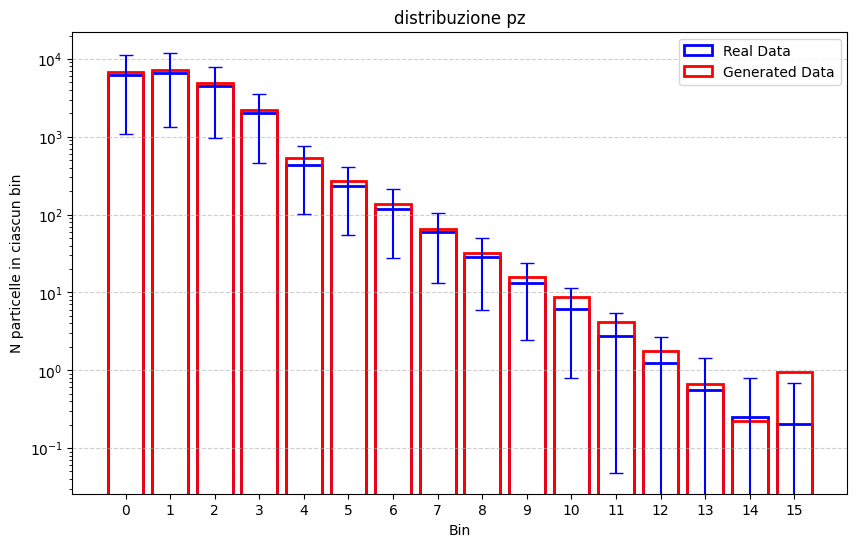

In [ ]:
bins = np.arange(len(pz_mean_real))

plt.figure(figsize=(10,6))
# plt.bar(bins, px_mean_real, yerr=px_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5))
# plt.bar(bins, px_mean_gen, yerr=px_std_gen, capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5) )
plt.bar(bins, pz_mean_real, yerr=pz_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5), label ="Real Data")
plt.bar(bins, pz_mean_gen,  capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5) , label ="Generated Data")

plt.xlabel("Bin")
plt.ylabel("N particelle in ciascun bin")
plt.title("distribuzione pz")
plt.xticks(bins)  # mostra i numeri dei bin sull'asse x
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.legend()

plt.show()

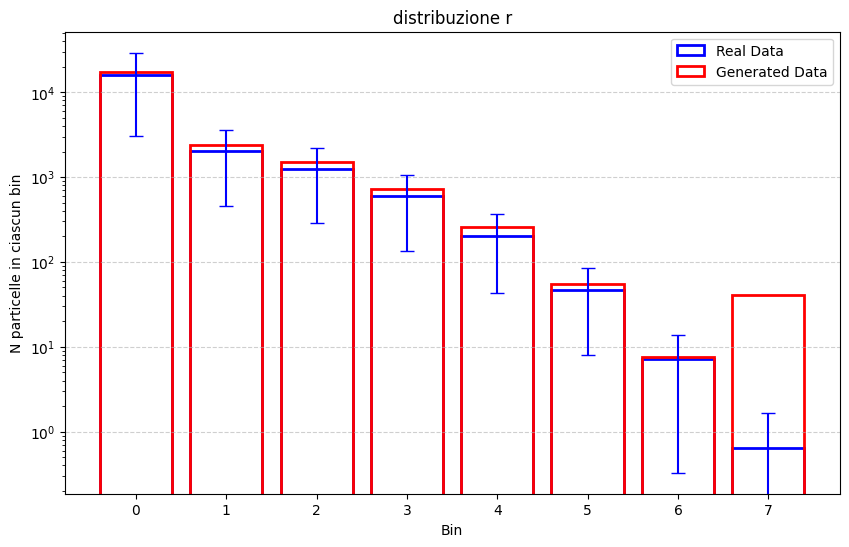

In [ ]:
bins = np.arange(len(r_mean_real))

plt.figure(figsize=(10,6))
# plt.bar(bins, px_mean_real, yerr=px_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5))
# plt.bar(bins, px_mean_gen, yerr=px_std_gen, capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5) )
plt.bar(bins, r_mean_real, yerr=r_std_real, capsize=5, facecolor="None", edgecolor="blue", linewidth=2, error_kw=dict(ecolor="blue", lw=1.5, capsize=5), label ="Real Data")
plt.bar(bins, r_mean_gen,  capsize=5, facecolor="None", edgecolor="red", linewidth=2,  error_kw=dict(ecolor="red", lw=1.5, capsize=5) , label ="Generated Data")

plt.xlabel("Bin")
plt.ylabel("N particelle in ciascun bin")
plt.title("distribuzione r")
plt.xticks(bins)  # mostra i numeri dei bin sull'asse x
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.legend()

plt.show()

## Diff Img

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from _GAN_utils import load_data

x_train, labels, network_details_stringa = load_data("../DataCorsika7/img_data/76310_1e6_2e7/", "1e6-2e7", "76310")
x_train2 = 10**(x_train*3.9) -1
Npart_vere_bins = x_train2

pat = "2025-09-14_10_05_29_WGAN_GP_corsika_NotConditioned_exceptfirst4_weigdecay_bigkernel/"

statistics = pd.read_csv(pat+"Statistiche_distr_num_part.csv")
epoche = statistics["epoch"].values
epoche[0] = 0 # altrimenti sarebbe "real data"


good_epochs = list(statistics[(statistics["Wasserstein_distance_from_real"]<0.1) * (statistics["epoch"].astype(int)>500)]["epoch"])
tuttigen = []
for epoca in good_epochs:
    tuttigen.append(np.load(pat+"epoca_"+epoca+"/gen_data.npy"))
tuttigen2 = np.concatenate(tuttigen, axis=0)
#tuttigen2 = np.load(pat+"epoca_"+"3870"+"/gen_data.npy")
Npart_generate_bins = tuttigen2

Npart_vere_bins_media =  Npart_vere_bins.mean(axis=0, keepdims=True)
Npart_generate_bins_media = Npart_generate_bins.mean(axis=0, keepdims=True)



loaded [22.27 s]
concatenated data [113.68 s]
block reduced data - 1 [243.71 s]
block reduced data - 2 [250.02 s]
concatenated un, du, tre [256.32 s]
Scaled data [264.78 s]


In [ ]:
Npart_vere_bins_media =  Npart_vere_bins.mean(axis=0, keepdims=True)
Npart_generate_bins_media = Npart_generate_bins.mean(axis=0, keepdims=True)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
try: 
    del plot_err_full
except:
    pass

def plot_err_full(vere, generate, indice, cmap="viridis", log=True, pathsave=None, th_npart=0):
    """
    Plot 4x3 matrix:
      - Rows: different 2D projections
          (px-py, pz-px, r-px, r-pz)
      - Columns: [MC Similation | Generate | Diff]
    """

    fig = plt.figure(figsize=(15, 20))
    gs = GridSpec(4, 4, figure=fig, width_ratios=[1, 1, 1, 0.05], height_ratios=[1, 1, 0.7, 0.7], hspace=-0.2, wspace=0.15)
    axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(4)])
    cbar_axes = [fig.add_subplot(gs[i, 3]) for i in range(4)]

    fontsize = 18

    def safe_log(arr):
        with np.errstate(divide='ignore', invalid='ignore'):
            return np.log10(arr)

    # --- Compute projections ---
    gpxpy = generate[indice].sum(axis=(-1, -2))
    vpxpy = vere[indice].sum(axis=(-1, -2))

    gpzpx = generate[indice].sum(axis=(1, -1)).T
    vpzpx = vere[indice].sum(axis=(1, -1)).T

    grpx = generate[indice].sum(axis=(1, 2)).T
    vrpx = vere[indice].sum(axis=(1, 2)).T

    grpz = generate[indice].sum(axis=(0, 1)).T
    vrpz = vere[indice].sum(axis=(0, 1)).T

    panels = [
        (gpxpy, vpxpy, "py", "px"),
        (gpzpx, vpzpx, "px", "pz"),
        (grpx, vrpx, "px", "r"),
        (grpz, vrpz, "pz", "r"),
    ]

    for i, (g, v, xlabel, ylabel) in enumerate(panels):
        # Apply mask
        mask = v < th_npart
        g = np.where(mask, 0, g)
        v = np.where(mask, 0, v)

        diff = np.abs(g - v)

        if log:
            data_v = safe_log(v)
            data_g = safe_log(g)
            data_diff = safe_log(diff)
        else:
            data_v, data_g, data_diff = v, g, diff

        # Remove -inf for color scale
        def finite_minmax(arr):
            arr_finite = arr[np.isfinite(arr)]
            return np.min(arr_finite), np.max(arr_finite)

        vmin_v, vmax_v = finite_minmax(data_v)
        vmin_g, vmax_g = finite_minmax(data_g)
        vmin_d, vmax_d = finite_minmax(data_diff)

        vmin = min(vmin_v, vmin_g, vmin_d)
        vmax = max(vmax_v, vmax_g, vmax_d)

        # Column 0 → Vere
        im0 = axes[i, 0].imshow(data_v, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[i, 0].set_ylabel(ylabel, fontsize=fontsize)
        axes[i, 0].set_xlabel(xlabel, fontsize=fontsize)

        # Column 1 → Generate
        im1 = axes[i, 1].imshow(data_g, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[i, 1].set_xlabel(xlabel, fontsize=fontsize)

        # Column 2 → Diff
        im2 = axes[i, 2].imshow(data_diff, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[i, 2].set_xlabel(xlabel, fontsize=fontsize)

        # Add titles only on first row
        if i == 0:
            axes[i, 0].set_title("CORSIKA simulation", fontsize=fontsize + 2)
            axes[i, 1].set_title("WGAN generated", fontsize=fontsize + 2)
            axes[i, 2].set_title("Difference", fontsize=fontsize + 2)

        # Invert y-axis for projections that need it
        
        axes[i, 0].invert_yaxis()
        axes[i, 1].invert_yaxis()
        axes[i, 2].invert_yaxis()

        pos = axes[i, -1].get_position()  # position of last subplot in row
        cbpos = cbar_axes[i].get_position()

        # center the colorbar vertically
        cbar_axes[i].set_position([
            cbpos.x0, 
            pos.y0,
            cbpos.width ,
            pos.height           
        ])
        cbar = fig.colorbar(im2, cax=cbar_axes[i])
        cbar.set_label("N particles (log scale)", fontsize=fontsize-4)


    if pathsave:
        plt.savefig(f"{pathsave}.png", bbox_inches='tight', dpi=300)
    plt.show()
    plt.clf()


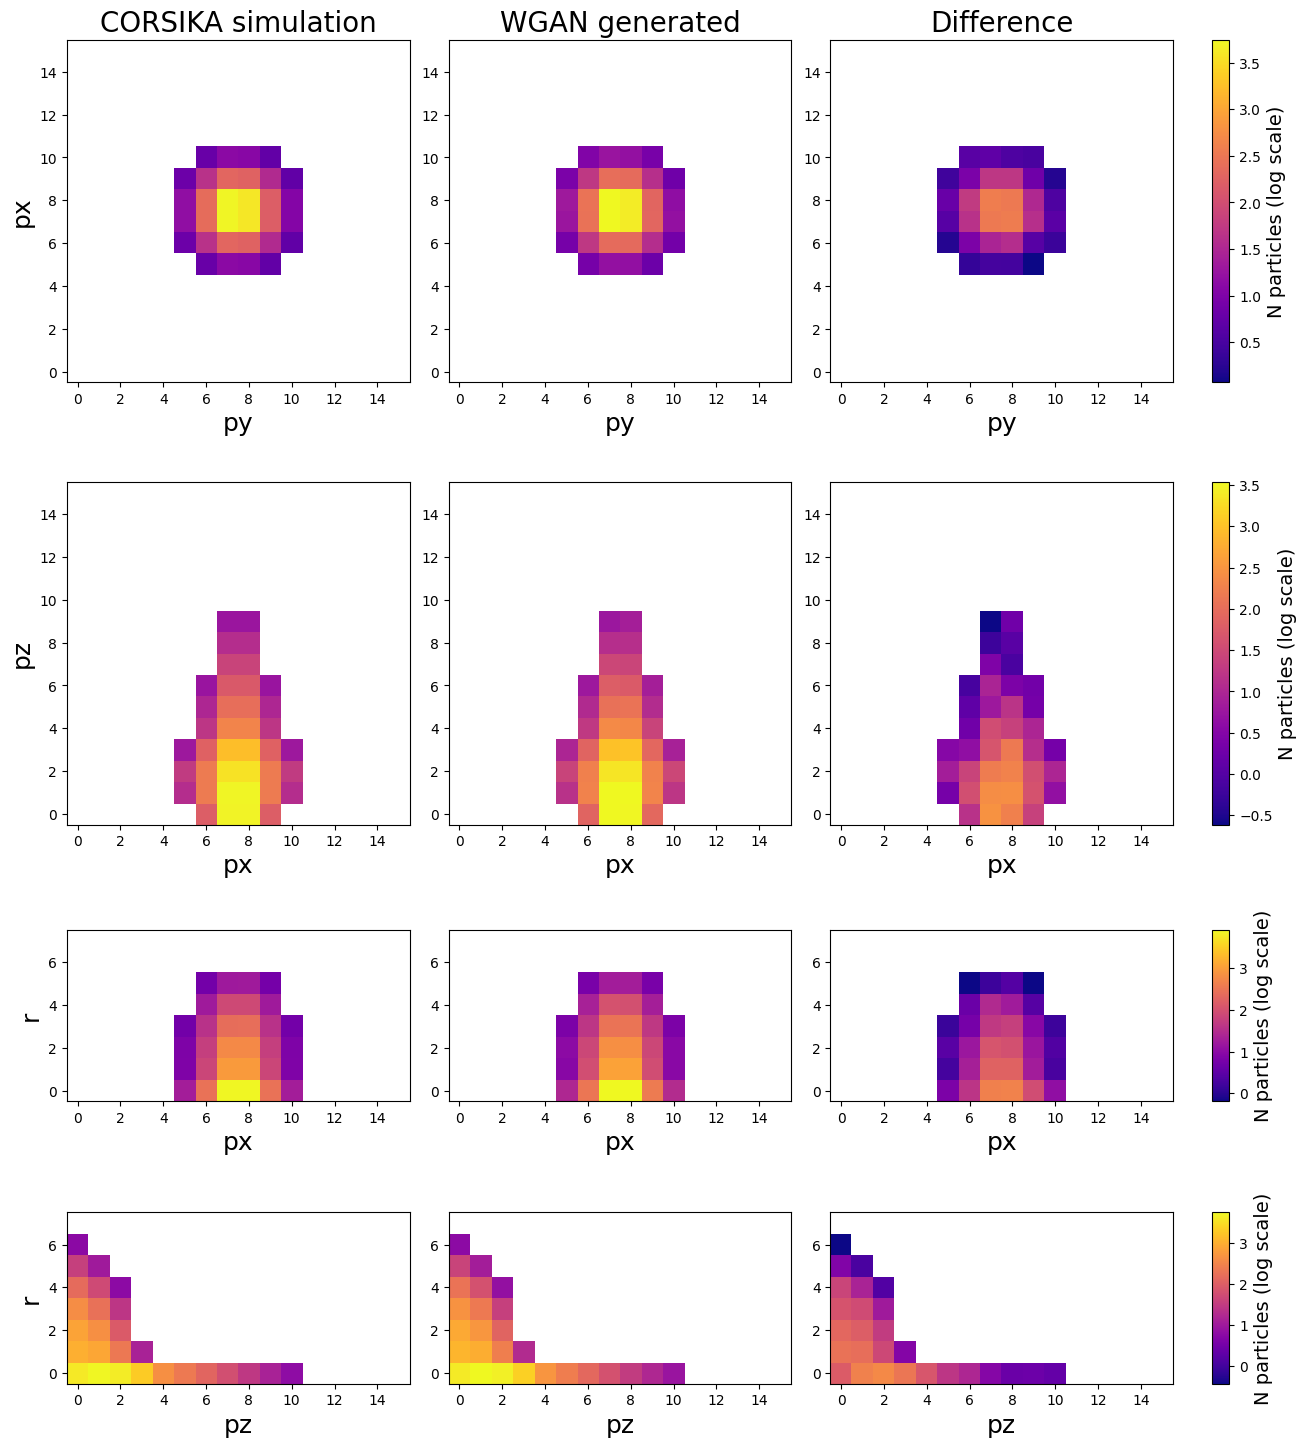

<Figure size 640x480 with 0 Axes>

In [ ]:
savepath = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"
plot_err_full(Npart_vere_bins_media, Npart_generate_bins_media, 0, cmap="plasma", log=True, th_npart=5, pathsave=f"{savepath}Mean_image_comparison")

## Verify Px/py = x/y

<>:46: SyntaxWarning: invalid escape sequence '\P'
<>:47: SyntaxWarning: invalid escape sequence '\P'
<>:46: SyntaxWarning: invalid escape sequence '\P'
<>:47: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_2319121/2010813837.py:46: SyntaxWarning: invalid escape sequence '\P'
  plt.xlabel("$\Phi_{p_T}$", fontsize=fontsz)
/tmp/ipykernel_2319121/2010813837.py:47: SyntaxWarning: invalid escape sequence '\P'
  plt.ylabel("$\Phi_r$", fontsize=fontsz)


9.0
7.71
9.0
7.71


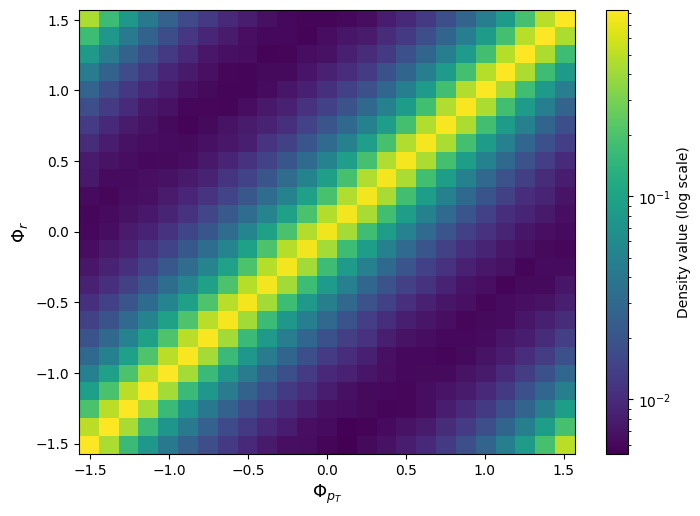

In [ ]:
from corsikaio import CorsikaParticleFile
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
from scipy.stats import circmean

ff1 = '../DataCorsika7/job9_contver76310_em_pr14_e1e6-1e7_z0-0/DAT000009' 
ff2 = '../DataCorsika7/job9_contver76310_em_pr14_e1e7-2e7_z0-0/DAT000009' 
savepath = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"
fontsz = 13

mu = []

# starting to read the Corsika file - selecting k-th event
with CorsikaParticleFile(ff1) as f:
    print(f.run_header['run_number'])
    print(f.version)
    
    for i,e in enumerate(f):
        mu.append(e.particles[(e.particles["particle_description"]>=6000) * (e.particles["particle_description"]<7000)])
        #print(i)
with CorsikaParticleFile(ff2) as f:
    print(f.run_header['run_number'])
    print(f.version)
    
    for i,e in enumerate(f):
        mu.append(e.particles[(e.particles["particle_description"]>=6000) * (e.particles["particle_description"]<7000)])
        #print(i)

mu = np.concatenate(mu, axis=0)

tetap = np.arctan(mu["py"]/mu["px"])      # angle of the pt
tetar = np.arctan(mu["y"]/mu["x"])        # angle of rt
#p = mu["py"]**2+mu["px"]**2+mu["pz"]**2   # total momentum


# plotting angle(rt) vs angle(pt) and the scatter related to the 300 most energetic
fig, ax = plt.subplots(figsize=(8,6))
#plt.title(f"Muons. Primary p+, Energy: GeV, Zen:0.0\nHistogram of Popolosity & scatter of the 300 most energetic muons"+
#         "\nScatter color intensity is related to particle p**2")
histptr=plt.hist2d(tetap,tetar,norm=colors.LogNorm(), bins=25, density=True)
#indexes = np.argsort(p)[-300:]
#plt.scatter(tetap[indexes],tetar[indexes], c=p[indexes],cmap="Reds", edgecolor="grey",norm=colors.LogNorm())


plt.xlabel("$\Phi_{p_T}$", fontsize=fontsz)
plt.ylabel("$\Phi_r$", fontsize=fontsz)
plt.colorbar(label="Density value (log scale)")
plt.subplots_adjust(top=0.85)  
plt.savefig(f"{savepath}Pt_vs_Rt.png", bbox_inches='tight', dpi=300)



In [37]:
phi_r = np.arctan2(mu["py"],mu["px"])      # angle of the pt
phi_pT = np.arctan2(mu["y"],mu["x"])        # angle of rt

mean_phi_r = circmean(phi_r, high=np.pi, low=-np.pi)
mean_phi_pT = circmean(phi_pT, high=np.pi, low=-np.pi)

num = np.sum(np.sin(phi_r - mean_phi_r) * np.sin(phi_pT - mean_phi_pT))
den = np.sqrt(np.sum(np.sin(phi_r - mean_phi_r)**2) * np.sum(np.sin(phi_pT - mean_phi_pT)**2))
rho_c = num / den
print(rho_c)

0.9385782


## Hist Npart

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# i stored in the file "N Particles 1e6_1e7.csv" the value of the number of particles in each event for the MC simulated data
npart_event = pd.read_csv("N Particles 1e6_1e7.csv")["Particles 1e6_1e7"].values 

log10_npart_event = np.log10(npart_event)

pat = "2025-09-14_10_05_29_WGAN_GP_corsika_NotConditioned_exceptfirst4_weigdecay_bigkernel/"

statistics = pd.read_csv("Statistiche_distr_num_part.csv")
epoche = statistics["epoch"].values
epoche[0] = 0 # altrimenti sarebbe "real data"

good_epochs = list(statistics[(statistics["Wasserstein_distance_from_real"]<0.1) * (statistics["epoch"].astype(int)>500)]["epoch"])


### Ensemble

In [ ]:
tuttigen = []
for epoca in good_epochs:
    tuttigen.append(np.load(pat+"epoca_"+epoca+"/gen_data.npy"))
tuttigen2 = np.concatenate(tuttigen, axis=0)
Npart_generate_bins = tuttigen2

dati_buoni_ensemble = np.log10(Npart_generate_bins.sum(axis=(1,2,3,4)))

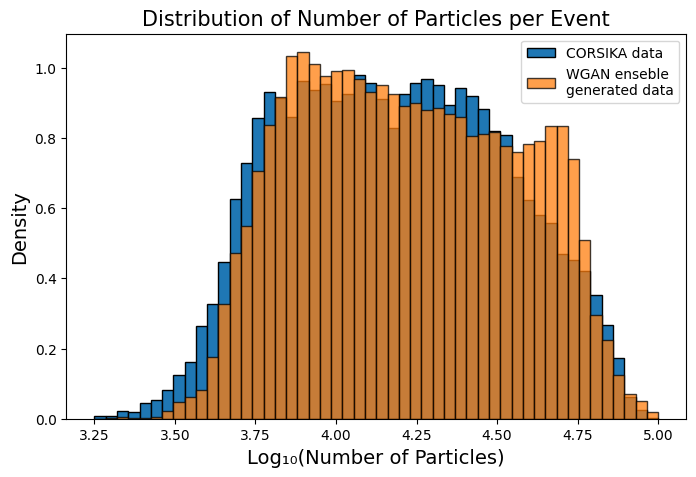

In [ ]:
savepath = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"
plt.figure(figsize=(8,5))
fsz = 14
a,bins, c = plt.hist(log10_npart_event, bins=50, range=(3.25,5), density=True, edgecolor="black", label="CORSIKA data")
plt.hist(dati_buoni_ensemble,bins=50,edgecolor="black",density=True, range=(3.25,5), label="WGAN enseble\ngenerated data",alpha=0.75)
plt.legend()
plt.xlabel("Log₁₀(Number of Particles)", fontsize=fsz)
plt.ylabel("Density", fontsize=fsz)
plt.title("Distribution of Number of Particles per Event", fontsize=fsz+1)
plt.savefig(savepath+"GAN_ensemble_Npart_distribution.png", bbox_inches='tight', dpi=300)

### Single GAN

In [ ]:
savepath = f"../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"
tuttigen = []
for epoca_ok in good_epochs:
    
    
    tuttigen.append(np.load(pat+"epoca_"+epoca+"/gen_data.npy"))
    
    Npart_generate_bins = tuttigen2

    dati_buoni_generated = np.log10(Npart_generate_bins.sum(axis=(1,2,3,4)))

    plt.figure(figsize=(8,5))
    fsz = 14
    a,bins, c = plt.hist(log10_npart_event, bins=50, range=(3.25,5), density=True, edgecolor="black", label="CORSIKA data")
    plt.hist(dati_buoni_generated,bins=50,edgecolor="black",density=True, range=(3.25,5), label="GAN enseble\ngenerated data",alpha=0.75)
    plt.legend()
    plt.xlabel("LOG_10(Number of Particles)", fontsize=fsz)
    plt.ylabel("Density", fontsize=fsz)
    plt.title("Distribution of Number of Particles per Event", fontsize=fsz+1)
    plt.savefig(savepath+"GAN_ensemble_Npart_distribution.png", bbox_inches='tight', dpi=300)

/tmp/ipykernel_2326449/11338222.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


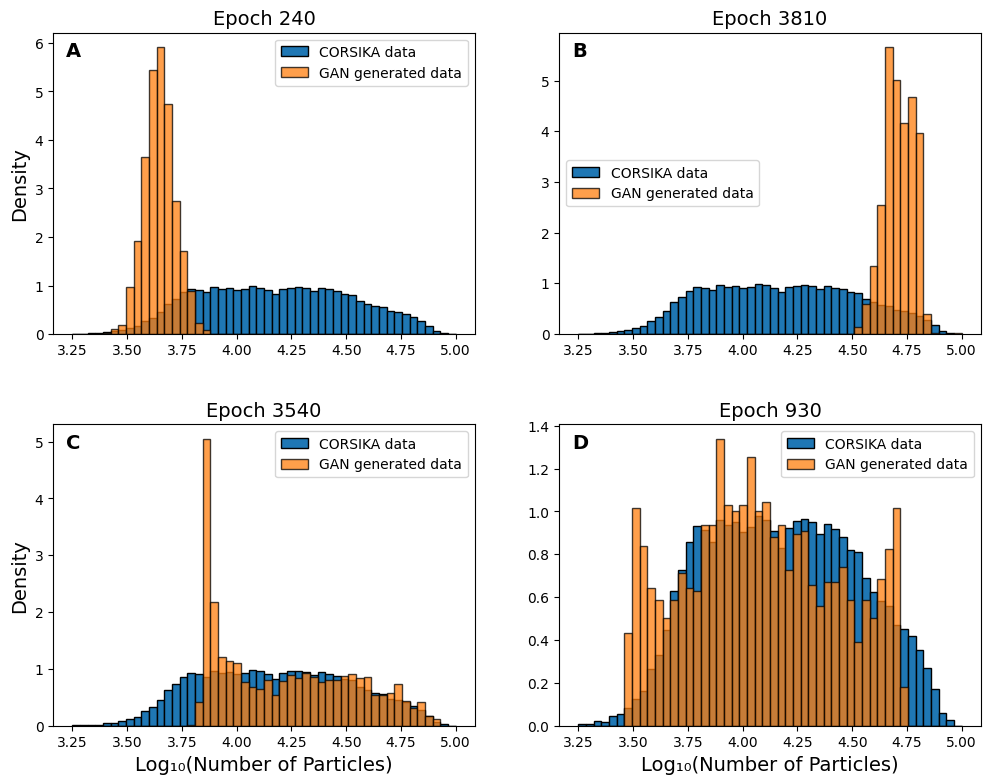

In [ ]:
savepath = "../GitHubFolders/GAN_GAIAS2/GAN/_Corsika/Imgs/"
fsz = 14
fig, axs = plt.subplots(2, 2, figsize=(13.3*.9, 10*.9),  gridspec_kw={'hspace': 0.3})
axs = axs.flatten()  # Flatten to easily index 0–3


labels = ['A', 'B', 'C', 'D']


for i, epoca_ok in enumerate([240,3810,3540,930]):
    # Load generated data
    gen_data = np.load(pat + f"epoca_{epoca_ok}/gen_data.npy")
    dati_buoni_generated = np.log10(gen_data.sum(axis=(1, 2, 3, 4)))

    # Plot on corresponding subplot
    ax = axs[i]
    ax.hist(log10_npart_event, bins=50, range=(3.25, 5), density=True,
            edgecolor="black", label="CORSIKA data")
    ax.hist(dati_buoni_generated, bins=50, range=(3.25, 5), density=True,
            edgecolor="black", alpha=0.75, label=f"GAN generated data")
    
    ax.set_title(f"Epoch {epoca_ok}", fontsize=fsz)
    
    if i % 2 == 0:
        ax.set_ylabel("Density", fontsize=fsz)
        
    if i in [2,3]:
        ax.set_xlabel("Log₁₀(Number of Particles)", fontsize=fsz)
    ax.text(.03, 0.97, labels[i], transform=ax.transAxes,
        fontsize=fsz, fontweight='bold', va='top', ha='left')
    ax.legend(fontsize=fsz - 4)

# Adjust layout and save
plt.tight_layout()
plt.savefig(savepath + "Epochs_Npart_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
savepathTMP = "Imgs/TMP/"
fsz = 14



labels = ['A', 'B', 'C', 'D']
tutteepoche = np.array([30*(i+2) for i in range(0,150-18)]).reshape((-1,4) ) # fino a 3870
for epocheora in tutteepoche:
    fig, axs = plt.subplots(2, 2, figsize=(12*.9, 10*.9),  gridspec_kw={'hspace': 0.3})
    axs = axs.flatten()  # Flatten to easily index 0–3
    
    for i, epoca_ok in enumerate(epocheora):
        # Load generated data
        gen_data = np.load(pat + f"epoca_{epoca_ok}/gen_data.npy")
        dati_buoni_generated = np.log10(gen_data.sum(axis=(1, 2, 3, 4)))

        # Plot on corresponding subplot
        ax = axs[i]
        ax.hist(log10_npart_event, bins=50, range=(3.25, 5), density=True,
                edgecolor="black", label="CORSIKA data")
        ax.hist(dati_buoni_generated, bins=50, range=(3.25, 5), density=True,
                edgecolor="black", alpha=0.75, label=f"GAN generated data")
        
        ax.set_title(f"Epoch {epoca_ok}", fontsize=fsz)
        
        if i % 2 == 0:
            ax.set_ylabel("Density", fontsize=fsz)
            
        if i in [2,3]:
            ax.set_xlabel("Log₁₀(Number of Particles)", fontsize=fsz)
        ax.text(1-0.06, 0.98, labels[i], transform=ax.transAxes,
            fontsize=fsz, fontweight='bold', va='top', ha='left')
        ax.legend(fontsize=fsz - 4)

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(savepathTMP + f"GAN_ensemble_Npart_distribution_panels_{epocheora[0]}.png", bbox_inches='tight', dpi=300)
    plt.clf()
#plt.show()

# Pixel occupancy - additional image

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from _GAN_utils import load_data

x_train, labels, network_details_stringa = load_data("../DataCorsika7/img_data/76310_1e6_2e7/", "1e6-2e7", "76310")
x_train2 = 10**(x_train*3.9) -1 # (go bak to number of particles)
Npart_vere_bins = x_train2

pat = "../2025-09-14_10_05_29_WGAN_GP_corsika_NotConditioned_exceptfirst4_weigdecay_bigkernel/"

statistics = pd.read_csv("Statistiche_distr_num_part.csv")
epoche = statistics["epoch"].values
epoche[0] = 0 # altrimenti sarebbe "real data"


good_epochs = list(statistics[(statistics["Wasserstein_distance_from_real"]<0.1) * (statistics["epoch"].astype(int)>500)]["epoch"])
tuttigen = []
for epoca in good_epochs:
    tuttigen.append(np.load(pat+"epoca_"+epoca+"/gen_data.npy"))
tuttigen2 = np.concatenate(tuttigen, axis=0)
#tuttigen2 = np.load(pat+"epoca_"+"3870"+"/gen_data.npy")
Npart_generate_bins = tuttigen2

N_pixel_vere = np.where(Npart_vere_bins>0, 1,0).sum(axis=(1,2,3,4))
N_pixel_gene = np.where(Npart_generate_bins>0, 1,0).sum(axis=(1,2,3,4))

2025-10-25 16:23:08.595643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-25 16:23:08.616914: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-25 16:23:08.623336: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-25 16:23:08.641423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-25 16:23:10.673180: W tensorflow/compiler/tf2

loaded [21.73 s]
concatenated data [45.05 s]
block reduced data - 1 [181.66 s]
block reduced data - 2 [187.22 s]
concatenated un, du, tre [193.59 s]
Scaled data [201.99 s]


(array([1.06945540e-06, 1.06945540e-06, 3.74309388e-06, 8.02091547e-06,
        2.08543802e-05, 3.42225727e-05, 6.09589576e-05, 1.06945540e-04,
        1.57209943e-04, 1.95710337e-04, 3.22975529e-04, 8.07973551e-04,
        2.05549327e-03, 2.64743683e-03, 3.17093525e-03, 3.56984211e-03,
        3.26130423e-03, 3.00463493e-03, 2.91907850e-03, 2.69342341e-03,
        2.67577740e-03, 2.51001181e-03, 2.34745459e-03, 2.30467638e-03,
        2.51054654e-03, 2.46028214e-03, 2.28970400e-03, 2.25334252e-03,
        1.99346486e-03, 1.95229082e-03, 1.66193368e-03, 1.79668506e-03,
        1.76192776e-03, 1.52076557e-03, 1.45713298e-03, 1.33895816e-03,
        1.15501183e-03, 1.06892067e-03, 7.37924223e-04, 5.13338590e-04,
        3.64149562e-04, 2.32071821e-04, 1.48654300e-04, 1.11758089e-04,
        7.59313331e-05, 6.30978683e-05, 5.50769529e-05, 1.55071032e-05,
        1.06945540e-06, 1.60418309e-06]),
 array([ 74.  ,  90.02, 106.04, 122.06, 138.08, 154.1 , 170.12, 186.14,
        202.16, 218.18

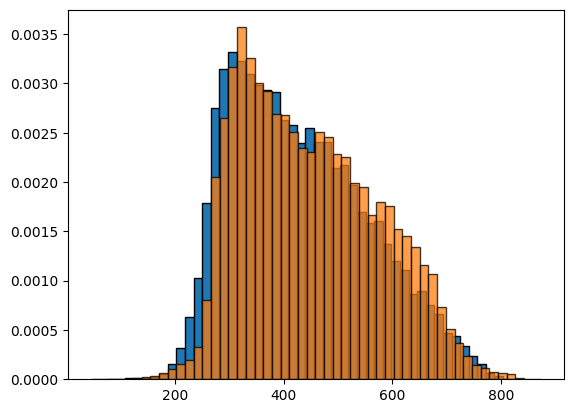

In [25]:
plt.hist(N_pixel_vere,bins=50,edgecolor="black",density=True)
plt.hist(N_pixel_gene,bins=50,edgecolor="black",alpha=0.75, density=True)